In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [24]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir('.'))

Current directory: /Users/albinsanthosh/Desktop/vlr-predictor

Files in current directory:
['app', 'requirements.txt', 'models', 'README.md', '.gitignore', '01_exploratory_data_analysis.ipynb', '.ipynb_checkpoints', 'venv', '.git', 'data', 'notebooks', 'src']


In [25]:
import os

# Print current location
print("Working from:", os.getcwd())

# Try different path options
if os.path.exists('../data/raw/recent_matches.csv'):
    # If notebook is in notebooks/ folder
    matches = pd.read_csv('../data/raw/recent_matches.csv')
    rankings = pd.read_csv('../data/raw/team_rankings_na.csv')
    players = pd.read_csv('../data/raw/player_stats_na_90d.csv')
elif os.path.exists('data/raw/recent_matches.csv'):
    # If notebook is in root folder
    matches = pd.read_csv('data/raw/recent_matches.csv')
    rankings = pd.read_csv('data/raw/team_rankings_na.csv')
    players = pd.read_csv('data/raw/player_stats_na_90d.csv')
else:
    # Find the files manually
    print("\n⚠️ Can't find data files. Checking...")
    for root, dirs, files in os.walk('.'):
        if 'recent_matches.csv' in files:
            print(f"Found data at: {root}")
            base_path = root
            matches = pd.read_csv(f'{base_path}/recent_matches.csv')
            rankings = pd.read_csv(f'{base_path}/team_rankings_na.csv')
            players = pd.read_csv(f'{base_path}/player_stats_na_90d.csv')
            break

print("\n" + "=" * 70)
print("DATA LOADED")
print("=" * 70)
print(f"Matches: {len(matches)} rows, {len(matches.columns)} columns")
print(f"Rankings: {len(rankings)} rows, {len(rankings.columns)} columns")
print(f"Players: {len(players)} rows, {len(players.columns)} columns")
print("=" * 70)

Working from: /Users/albinsanthosh/Desktop/vlr-predictor

DATA LOADED
Matches: 50 rows, 12 columns
Rankings: 405 rows, 9 columns
Players: 348 rows, 15 columns


In [26]:
# Display first few matches
print("First 5 Matches:")
print(matches.head())

print("\n" + "=" * 70)
print("Match Data Info:")
print(matches.info())

print("\n" + "=" * 70)
print("Missing Values:")
print(matches.isnull().sum())

First 5 Matches:
                     team1                 team2  score1  score2    flag1  \
0          Karmine Corp GC      AlQadsiah Corals       1       2  flag_eu   
1         ZennIT Orange GC          Zerance Mint       1       2  flag_eu   
2                SK Nebula  Twisted Minds Orchid       0       2  flag_eu   
3                 G2 Gozen              BLVKHVND       0       2  flag_eu   
4  Ambitious Legend Gaming             Rare Atom       0       2  flag_cn   

     flag2 time_completed                round_info  \
0  flag_tr     5h 58m ago        Group Stage-Week 4   
1  flag_fr     5h 58m ago        Group Stage-Week 4   
2  flag_sa     8h 13m ago        Group Stage-Week 4   
3  flag_tr     8h 13m ago        Group Stage-Week 4   
4  flag_cn    12h 13m ago  Group Stage-Winner's (B)   

                    tournament_name  \
0  Game Changers 2025: EMEA Stage 3   
1  Game Changers 2025: EMEA Stage 3   
2  Game Changers 2025: EMEA Stage 3   
3  Game Changers 2025: EMEA Stage

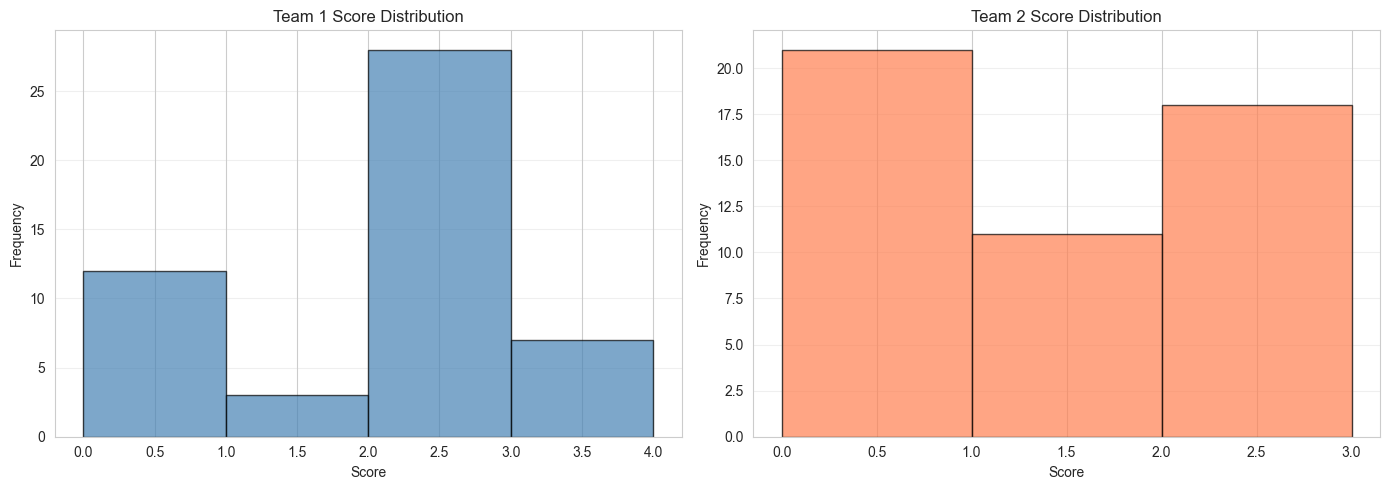

Average Team 1 Score: 1.60
Average Team 2 Score: 0.94


In [27]:
# Visualize score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Team 1 scores
axes[0].hist(matches['score1'], bins=range(0, matches['score1'].max()+2), 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Team 1 Score Distribution')
axes[0].grid(axis='y', alpha=0.3)

# Team 2 scores
axes[1].hist(matches['score2'], bins=range(0, matches['score2'].max()+2), 
             color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Team 2 Score Distribution')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Team 1 Score: {matches['score1'].mean():.2f}")
print(f"Average Team 2 Score: {matches['score2'].mean():.2f}")

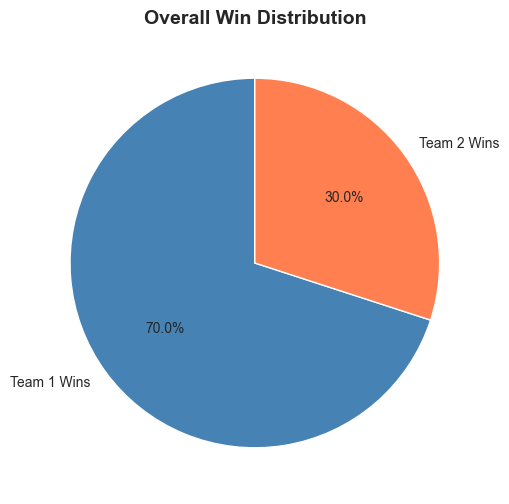

Team 1 Win Rate: 70.0%
Team 2 Win Rate: 30.0%

💡 Insight: Significant home-field advantage?


In [28]:
# Calculate win rates
matches['team1_won'] = matches['score1'] > matches['score2']
matches['team2_won'] = matches['score2'] > matches['score1']

team1_wins = matches['team1_won'].sum()
team2_wins = matches['team2_won'].sum()
total_matches = len(matches)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
win_data = [team1_wins, team2_wins]
colors = ['steelblue', 'coral']
labels = ['Team 1 Wins', 'Team 2 Wins']

wedges, texts, autotexts = ax.pie(win_data, labels=labels, colors=colors, 
                                    autopct='%1.1f%%', startangle=90)
ax.set_title('Overall Win Distribution', fontsize=14, fontweight='bold')

plt.show()

print(f"Team 1 Win Rate: {team1_wins/total_matches*100:.1f}%")
print(f"Team 2 Win Rate: {team2_wins/total_matches*100:.1f}%")
print(f"\n💡 Insight: {'Relatively balanced' if abs(team1_wins - team2_wins) < 5 else 'Significant home-field advantage?' }")

Matches by Tournament:
tournament_name
Game Changers 2025: EMEA Stage 3             21
Game Changers 2025: North America Stage 2    10
VCT 2025: China Ascension                     6
Game Changers 2025: Pacific                   6
Game Changers 2025: Brazil Finals             4
Game Changers 2025: China Stage 2             2
Red Bull Home Ground 2025 EMEA Qualifiers     1
Name: count, dtype: int64


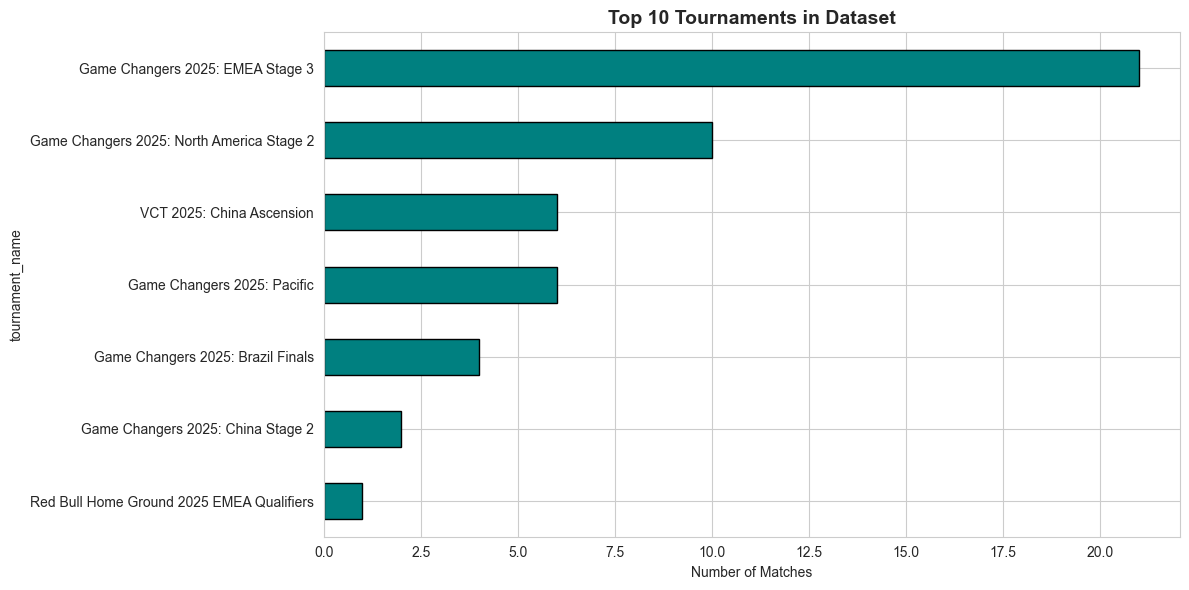

In [29]:
# Analyze tournament distribution
tournament_counts = matches['tournament_name'].value_counts()

print("Matches by Tournament:")
print(tournament_counts)

# Visualization
plt.figure(figsize=(12, 6))
tournament_counts.head(10).plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Number of Matches')
plt.title('Top 10 Tournaments in Dataset', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Top 10 Teams by Win Rate (min 20 games):
    rank                  team  wins  losses  win_rate earnings
2      3                  ENVY    35       5  0.875000  $48,000
6      7                   QoR    40       9  0.816327   $9,200
17    18               Pigeons   167      38  0.814634   $7,185
15    16                Dynamo    59      15  0.797297   $3,625
14    15     Nightblood Gaming   111      30  0.787234  $11,745
11    12            Blue Otter   183      52  0.778723  $12,835
21    22         happy esports    24       7  0.774194     $250
10    11  Maryville University    76      27  0.737864  $27,175
18    19           SaD Esports    39      14  0.735849   $5,119
27    28        ALPHA MADE LLC    22       8  0.733333     $275


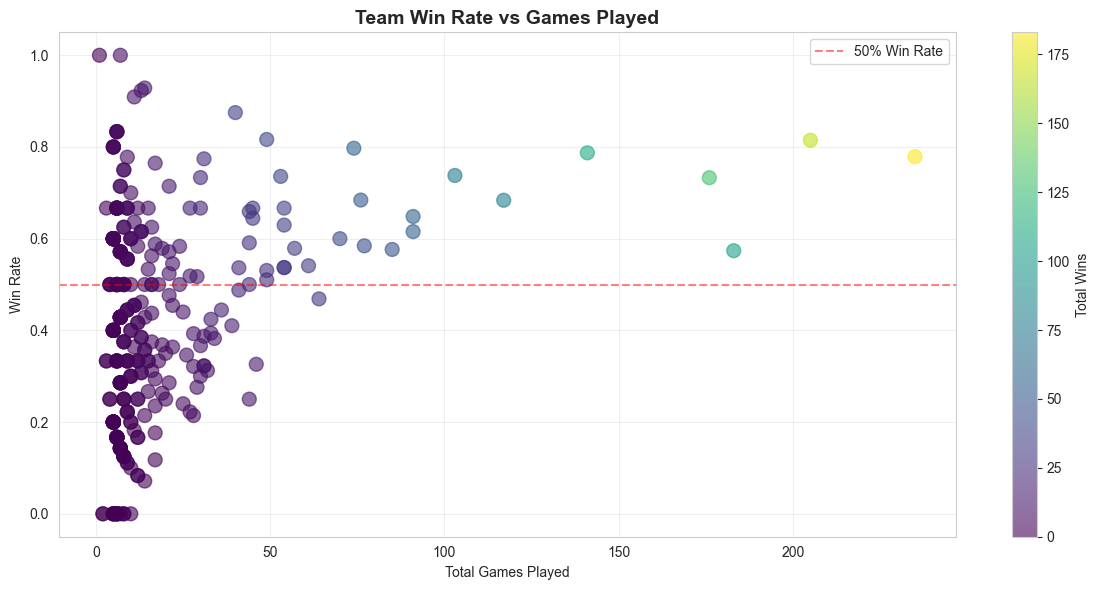

In [30]:
# Clean up the record column (format: "W-L")
rankings[['wins', 'losses']] = rankings['record'].str.split('–', expand=True)
rankings['wins'] = pd.to_numeric(rankings['wins'])
rankings['losses'] = pd.to_numeric(rankings['losses'])
rankings['total_games'] = rankings['wins'] + rankings['losses']
rankings['win_rate'] = rankings['wins'] / rankings['total_games']

# Display top teams
print("Top 10 Teams by Win Rate (min 20 games):")
top_teams = rankings[rankings['total_games'] >= 20].nlargest(10, 'win_rate')
print(top_teams[['rank', 'team', 'wins', 'losses', 'win_rate', 'earnings']])

# Visualization
plt.figure(figsize=(12, 6))
plt.scatter(rankings['total_games'], rankings['win_rate'], 
           alpha=0.6, s=100, c=rankings['wins'], cmap='viridis')
plt.colorbar(label='Total Wins')
plt.xlabel('Total Games Played')
plt.ylabel('Win Rate')
plt.title('Team Win Rate vs Games Played', fontsize=14, fontweight='bold')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% Win Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Top 10 Players by Rating:
      player     org  rating  average_combat_score  kill_deaths
0  StarBound    WADA    1.36                 257.6         1.59
1     terror    HAKI    1.25                 256.4         1.27
2        sym     TSM    1.24                 280.8         1.26
3        Bob     FLY    1.23                 235.5         1.29
4   Timotino     TSM    1.22                 264.8         1.30
5    cuteasa  YDZ.GC    1.21                 252.3         1.18
6      edith    GHST    1.21                 253.3         1.29
7        eli     TNX    1.20                 231.5         1.20
8      ion2x      NV    1.19                 225.9         1.25
9      penny     APK    1.19                 252.3         1.25


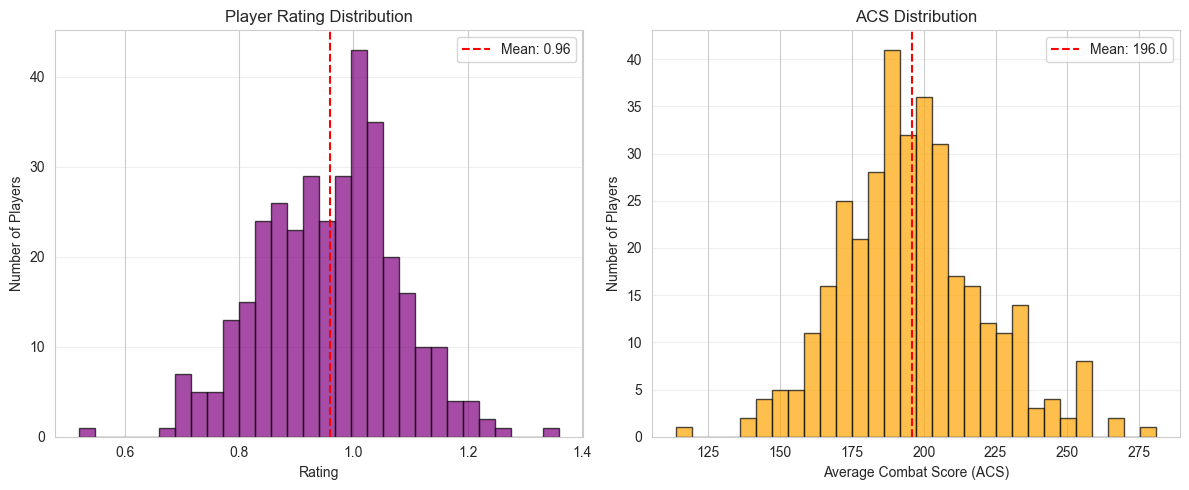

In [31]:
# Convert rating and ACS to numeric
players['rating'] = pd.to_numeric(players['rating'])
players['average_combat_score'] = pd.to_numeric(players['average_combat_score'])
players['kill_deaths'] = pd.to_numeric(players['kill_deaths'])

# Top performers
print("Top 10 Players by Rating:")
print(players.nlargest(10, 'rating')[['player', 'org', 'rating', 'average_combat_score', 'kill_deaths']])

# Rating distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(players['rating'], bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Rating')
plt.ylabel('Number of Players')
plt.title('Player Rating Distribution')
plt.axvline(players['rating'].mean(), color='red', linestyle='--', label=f'Mean: {players["rating"].mean():.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(players['average_combat_score'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.xlabel('Average Combat Score (ACS)')
plt.ylabel('Number of Players')
plt.title('ACS Distribution')
plt.axvline(players['average_combat_score'].mean(), color='red', linestyle='--', 
           label=f'Mean: {players["average_combat_score"].mean():.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

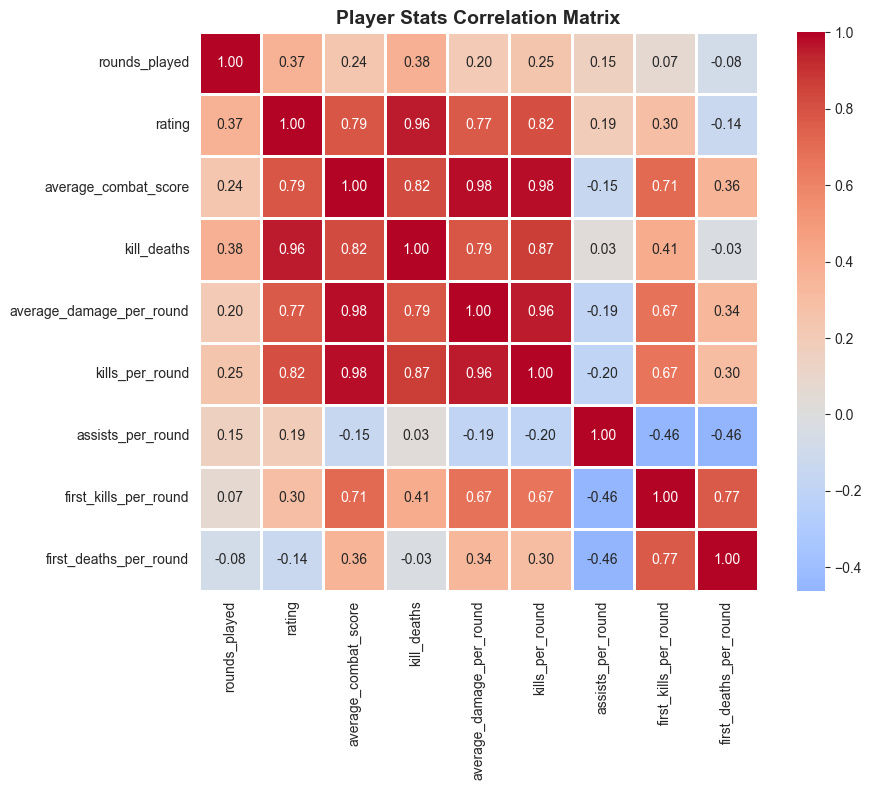


Key Correlations with Rating:
rating                      1.000000
kill_deaths                 0.956680
kills_per_round             0.815789
average_combat_score        0.787629
average_damage_per_round    0.768598
rounds_played               0.369250
first_kills_per_round       0.297075
assists_per_round           0.194837
first_deaths_per_round     -0.138963
Name: rating, dtype: float64


In [32]:
# Select numeric columns for correlation
player_numeric = players.select_dtypes(include=[np.number])

# Correlation matrix
plt.figure(figsize=(10, 8))
correlation = player_numeric.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1)
plt.title('Player Stats Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Correlations with Rating:")
print(correlation['rating'].sort_values(ascending=False))

In [33]:
print("=" * 70)
print("🔍 KEY INSIGHTS FOR ML MODEL")
print("=" * 70)

print(f"\n1. DATA VOLUME:")
print(f"   • {len(matches)} matches (need 500-1000+ for robust model)")
print(f"   • {len(rankings)} teams tracked")
print(f"   • {len(players)} players with stats")

print(f"\n2. MATCH OUTCOMES:")
print(f"   • Team 1 wins: {team1_wins/total_matches*100:.1f}%")
print(f"   • Team 2 wins: {team2_wins/total_matches*100:.1f}%")
print(f"   • Average score difference: {abs(matches['score1'] - matches['score2']).mean():.2f}")

print(f"\n3. AVAILABLE FEATURES:")
print(f"   Team names and regions")
print(f"   Tournament context")
print(f"   Team rankings and win rates")
print(f"   Player performance stats")
print(f"   Missing: Map-specific data, head-to-head history, recent form")

print(f"\n4. NEXT STEPS:")
print(f"   1. Collect more historical match data (target: 1000+ matches)")
print(f"   2. Add temporal features (date/time of matches)")
print(f"   3. Engineer features: head-to-head records, recent form, team composition")
print(f"   4. Build baseline ML model")

print("=" * 70)

🔍 KEY INSIGHTS FOR ML MODEL

1. DATA VOLUME:
   • 50 matches (need 500-1000+ for robust model)
   • 405 teams tracked
   • 348 players with stats

2. MATCH OUTCOMES:
   • Team 1 wins: 70.0%
   • Team 2 wins: 30.0%
   • Average score difference: 1.74

3. AVAILABLE FEATURES:
   Team names and regions
   Tournament context
   Team rankings and win rates
   Player performance stats
   Missing: Map-specific data, head-to-head history, recent form

4. NEXT STEPS:
   1. Collect more historical match data (target: 1000+ matches)
   2. Add temporal features (date/time of matches)
   3. Engineer features: head-to-head records, recent form, team composition
   4. Build baseline ML model
